In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('diabetes.csv')

In [4]:
df.head()

,Age,Gender,BMI,SBP,DBP,FPG,Chol,Tri,HDL,LDL,ALT,BUN,CCR,FFPG,smoking,drinking,family_histroy,Diabetes
0,26,1,20.1,119,81,5.80,4.36,0.86,0.90,2.43,12.0,5.40,63.8,5.40,3.0,3.0,0,0
1,40,1,17.7,97,54,4.60,3.70,1.02,1.50,2.04,9.2,3.70,70.3,4.10,1.0,1.0,0,0
2,40,2,19.7,85,53,5.30,5.87,1.29,1.75,3.37,10.1,4.10,61.1,4.85,3.0,3.0,0,0
3,43,1,23.1,111,71,4.50,4.05,0.74,1.27,2.60,36.5,4.38,73.4,5.30,2.0,3.0,0,0
4,36,1,26.5,130,82,5.54,6.69,3.49,0.91,3.64,69.3,3.86,67.5,5.53,3.0,3.0,0,0


In [5]:
df.isna().sum()

Age               0
Gender            0
BMI               0
SBP               0
DBP               0
FPG               0
Chol              0
Tri               0
HDL               0
LDL               0
ALT               0
BUN               0
CCR               0
FFPG              0
smoking           0
drinking          0
family_histroy    0
Diabetes          0
dtype: int64

In [6]:
df['smoking'].unique()

array([3.      , 1.      , 2.      , 4.860753])

In [7]:
df['drinking'].unique()

array([3.      , 1.      , 2.      , 4.860753])

In [8]:
df['smoking'] = df['smoking'].replace(1, 'Never')
df['smoking'] = df['smoking'].replace(2, 'Past')
df['smoking'] = df['smoking'].replace(3, 'Occational')
df['smoking'] = df['smoking'].replace(4.860753, 'Daily')

In [9]:
df['smoking'].unique()

array(['Occational', 'Never', 'Past', 'Daily'], dtype=object)

In [10]:
df['drinking'] = df['drinking'].replace(1, 'Never')
df['drinking'] = df['drinking'].replace(2, 'Past')
df['drinking'] = df['drinking'].replace(3, 'Occational')
df['drinking'] = df['drinking'].replace(4.860753, 'Daily')

In [11]:
df['drinking'].unique()

array(['Occational', 'Never', 'Past', 'Daily'], dtype=object)

In [12]:
df.head()

,Age,Gender,BMI,SBP,DBP,FPG,Chol,Tri,HDL,LDL,ALT,BUN,CCR,FFPG,smoking,drinking,family_histroy,Diabetes
0,26,1,20.1,119,81,5.80,4.36,0.86,0.90,2.43,12.0,5.40,63.8,5.40,Occational,Occational,0,0
1,40,1,17.7,97,54,4.60,3.70,1.02,1.50,2.04,9.2,3.70,70.3,4.10,Never,Never,0,0
2,40,2,19.7,85,53,5.30,5.87,1.29,1.75,3.37,10.1,4.10,61.1,4.85,Occational,Occational,0,0
3,43,1,23.1,111,71,4.50,4.05,0.74,1.27,2.60,36.5,4.38,73.4,5.30,Past,Occational,0,0
4,36,1,26.5,130,82,5.54,6.69,3.49,0.91,3.64,69.3,3.86,67.5,5.53,Occational,Occational,0,0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4303 entries, 0 to 4302
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             4303 non-null   int64  
 1   Gender          4303 non-null   int64  
 2   BMI             4303 non-null   float64
 3   SBP             4303 non-null   int64  
 4   DBP             4303 non-null   int64  
 5   FPG             4303 non-null   float64
 6   Chol            4303 non-null   float64
 7   Tri             4303 non-null   float64
 8   HDL             4303 non-null   float64
 9   LDL             4303 non-null   float64
 10  ALT             4303 non-null   float64
 11  BUN             4303 non-null   float64
 12  CCR             4303 non-null   float64
 13  FFPG            4303 non-null   float64
 14  smoking         4303 non-null   object 
 15  drinking        4303 non-null   object 
 16  family_histroy  4303 non-null   int64  
 17  Diabetes        4303 non-null   i

In [14]:
print(df['drinking'].unique())
print(df['smoking'].unique())

['Occational' 'Never' 'Past' 'Daily']
['Occational' 'Never' 'Past' 'Daily']


In [15]:
from sklearn.preprocessing import OneHotEncoder
oe = OneHotEncoder(sparse_output=False)

In [16]:
temp1=oe.fit_transform(df[['smoking']])
smoking_cols = oe.get_feature_names_out(['smoking'])

In [17]:
temp2=oe.fit_transform(df[['drinking']])
drinking_cols = oe.get_feature_names_out(['drinking'])

In [18]:
smoking_cols,drinking_cols

(array(['smoking_Daily', 'smoking_Never', 'smoking_Occational',
        'smoking_Past'], dtype=object),
 array(['drinking_Daily', 'drinking_Never', 'drinking_Occational',
        'drinking_Past'], dtype=object))

In [19]:
temp1_sm=pd.DataFrame(temp1,columns=smoking_cols,index=df.index)
temp2_dr=pd.DataFrame(temp2,columns=drinking_cols,index=df.index)


In [20]:
df=pd.concat([df,temp1_sm,temp2_dr],axis=1)

In [21]:
df.head()

,Age,Gender,BMI,SBP,DBP,FPG,Chol,Tri,HDL,LDL,...,family_histroy,Diabetes,smoking_Daily,smoking_Never,smoking_Occational,smoking_Past,drinking_Daily,drinking_Never,drinking_Occational,drinking_Past
0,26,1,20.1,119,81,5.80,4.36,0.86,0.90,2.43,...,0,0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,40,1,17.7,97,54,4.60,3.70,1.02,1.50,2.04,...,0,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,40,2,19.7,85,53,5.30,5.87,1.29,1.75,3.37,...,0,0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,43,1,23.1,111,71,4.50,4.05,0.74,1.27,2.60,...,0,0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,36,1,26.5,130,82,5.54,6.69,3.49,0.91,3.64,...,0,0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [22]:
df.drop(columns=['smoking','drinking'],inplace=True)

In [23]:
df.head()

,Age,Gender,BMI,SBP,DBP,FPG,Chol,Tri,HDL,LDL,...,family_histroy,Diabetes,smoking_Daily,smoking_Never,smoking_Occational,smoking_Past,drinking_Daily,drinking_Never,drinking_Occational,drinking_Past
0,26,1,20.1,119,81,5.80,4.36,0.86,0.90,2.43,...,0,0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,40,1,17.7,97,54,4.60,3.70,1.02,1.50,2.04,...,0,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,40,2,19.7,85,53,5.30,5.87,1.29,1.75,3.37,...,0,0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,43,1,23.1,111,71,4.50,4.05,0.74,1.27,2.60,...,0,0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,36,1,26.5,130,82,5.54,6.69,3.49,0.91,3.64,...,0,0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4303 entries, 0 to 4302
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  4303 non-null   int64  
 1   Gender               4303 non-null   int64  
 2   BMI                  4303 non-null   float64
 3   SBP                  4303 non-null   int64  
 4   DBP                  4303 non-null   int64  
 5   FPG                  4303 non-null   float64
 6   Chol                 4303 non-null   float64
 7   Tri                  4303 non-null   float64
 8   HDL                  4303 non-null   float64
 9   LDL                  4303 non-null   float64
 10  ALT                  4303 non-null   float64
 11  BUN                  4303 non-null   float64
 12  CCR                  4303 non-null   float64
 13  FFPG                 4303 non-null   float64
 14  family_histroy       4303 non-null   int64  
 15  Diabetes             4303 non-null   i

In [25]:
dep=df['Diabetes']
inde=df.drop('Diabetes',axis=1)

In [26]:
w=inde.merge(dep,left_index=True,right_index=True)

<Axes: >

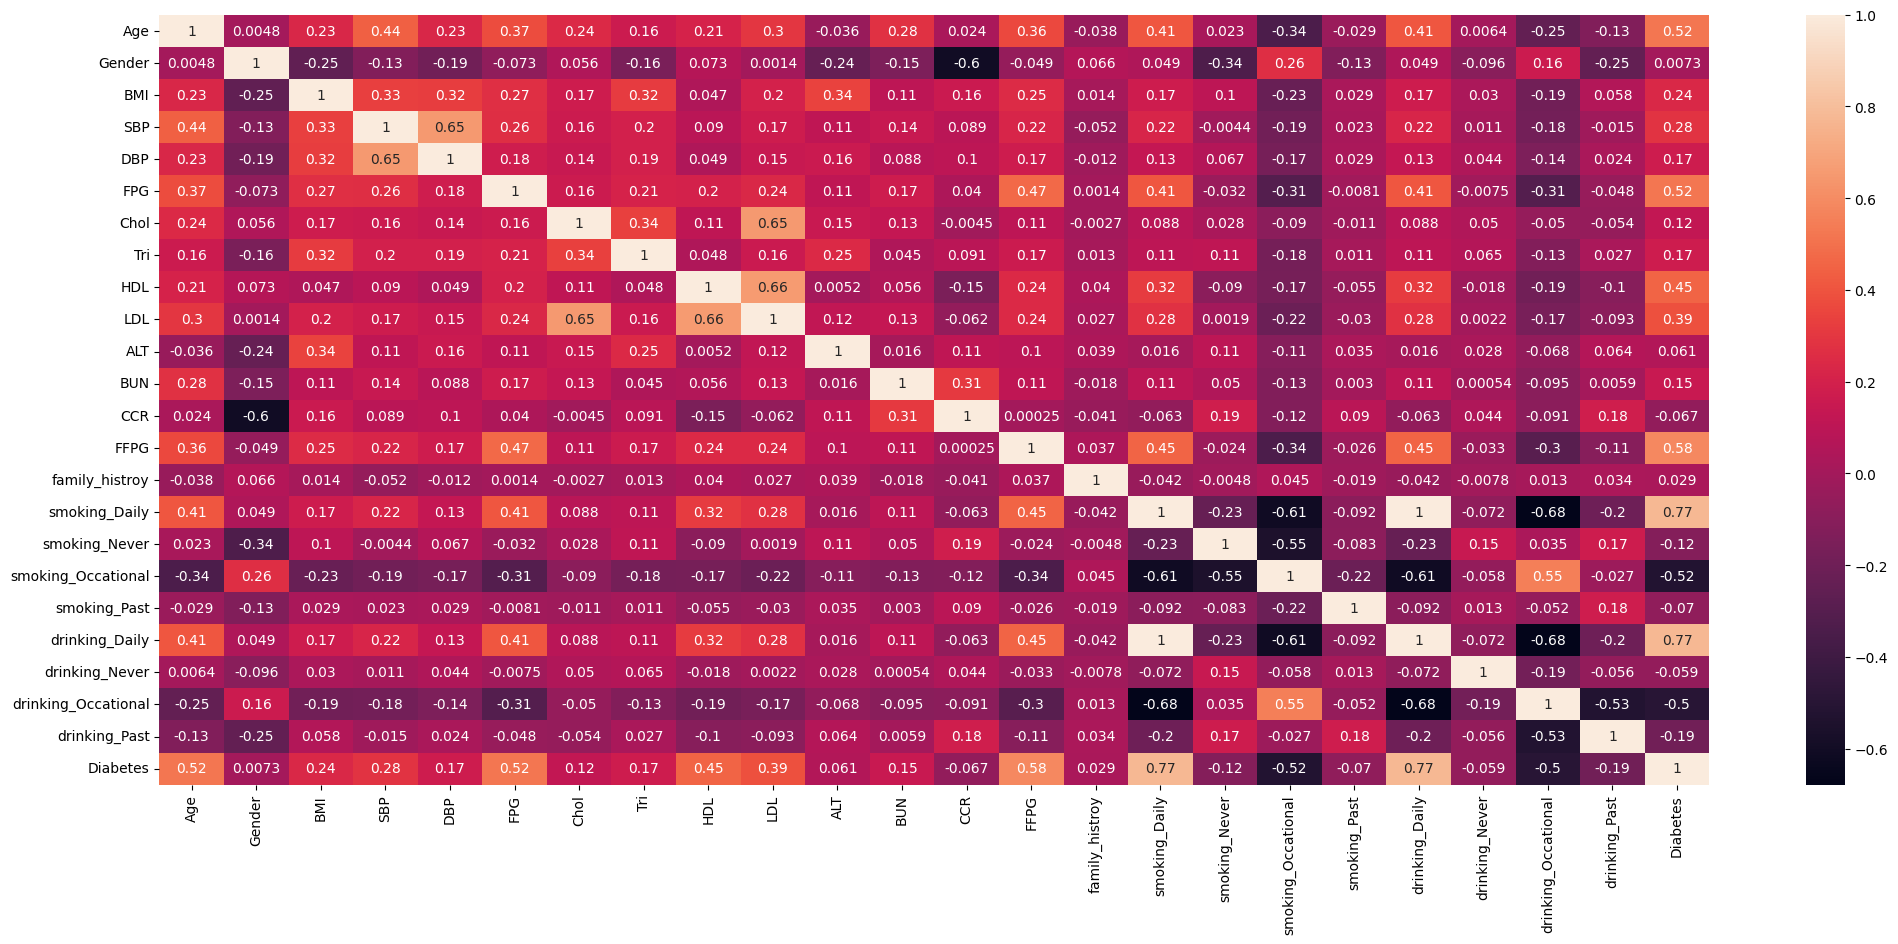

In [27]:
plt.figure(figsize=(25,10))
sns.heatmap(w.corr(),annot=True)

In [28]:
X=df.drop('Diabetes',axis=1)
y=df['Diabetes']

In [29]:
X.drop(columns=['family_histroy'],inplace=True)

In [30]:
X.head()

,Age,Gender,BMI,SBP,DBP,FPG,Chol,Tri,HDL,LDL,...,CCR,FFPG,smoking_Daily,smoking_Never,smoking_Occational,smoking_Past,drinking_Daily,drinking_Never,drinking_Occational,drinking_Past
0,26,1,20.1,119,81,5.80,4.36,0.86,0.90,2.43,...,63.8,5.40,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,40,1,17.7,97,54,4.60,3.70,1.02,1.50,2.04,...,70.3,4.10,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,40,2,19.7,85,53,5.30,5.87,1.29,1.75,3.37,...,61.1,4.85,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,43,1,23.1,111,71,4.50,4.05,0.74,1.27,2.60,...,73.4,5.30,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,36,1,26.5,130,82,5.54,6.69,3.49,0.91,3.64,...,67.5,5.53,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [31]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=10)

In [32]:
from sklearn.linear_model import LogisticRegression
logistic=LogisticRegression()

In [33]:
logistic.fit(X_train,y_train)

C:\Users\nalla\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [34]:
y_pred=logistic.predict(X_test)

In [35]:
y_pred

array([1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [36]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [37]:
accuracy_score(y_test,y_pred)

0.9709639953542393

In [38]:
confusion_matrix(y_test,y_pred)

array([[604,   7],
       [ 18, 232]])

In [39]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       611
           1       0.97      0.93      0.95       250

    accuracy                           0.97       861
   macro avg       0.97      0.96      0.96       861
weighted avg       0.97      0.97      0.97       861



In [40]:
import pickle
pickle.dump(oe,open('oe.pkl','wb'))
pickle.dump(logistic,open('logistic.pkl','wb'))